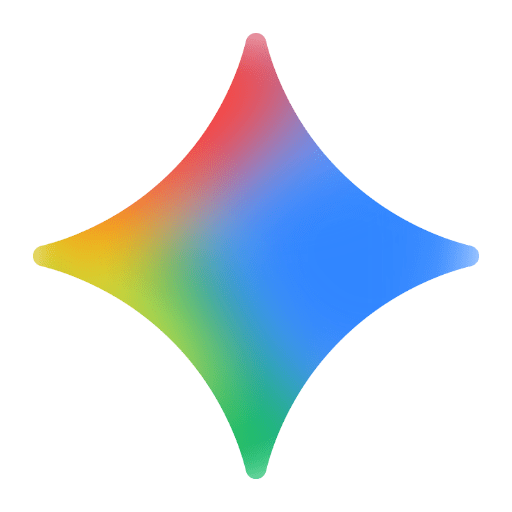

# Chapter 10: Conversational and Content Creation Agents

**Book:** *30 Agents Every AI Engineer Must Build*  
**Author:** Imran Ahmad  

Powered by **Google Gemini Flash 2.5**
**Publisher:** Packt Publishing, 2026  
**Chapter Pages:** pp. 281–306

---

> *"We can only see a short distance ahead, but we can see plenty there that needs to be done."*
> — Alan M. Turing

## Introduction

Conversational and Content Creation agents represent the creative and social interface of artificial intelligence. Unlike software development agents that prioritize syntactic correctness and logic, these agents must master the nuances of **tone, context, empathy, and aesthetic coherence**. They transform raw generative potential into structured, meaningful interactions that prioritize engaging users and producing high-value content.

For the engineer, the core challenge is designing systems that **sustain coherent behavior across long interactions**, enforce safety and brand constraints deterministically, and coordinate multiple generation stages without sacrificing reliability.

### What This Notebook Covers

1. **The Conversational Agent** (§10.1, pp. 282–293) — A safety-aware agent with a dual-memory hierarchy (working memory via `ConversationSummaryBufferMemory` and semantic long-term recall via FAISS), a deterministic `SafetyLayer` sentinel, and a `PersonaEngine` that enforces empathetic, non-directive behavior as a constraint layer. Demonstrated through a mental health support agent case study.

2. **The Content Creation Agent** (§10.2, pp. 293–305) — A multi-agent content creation pipeline built on the SMPA (Sense-Model-Plan-Act) paradigm. Specialist agents (Email, SEO, Ad Creative) produce brand-constrained drafts validated by an `EditorAgent` using a CSP (Constraint Satisfaction Problem) framework, with an `AnalyticsEngine` closing the adaptive feedback loop.

### Key Architectural Principles

Both agent types share a **boundary-first** design philosophy:

- **Safety before generation** — Crisis detection and brand constraints are enforced *upstream* of all generative logic, never as afterthoughts
- **Persona as controlled bias** — Personality is not randomness; it is a set of behavioral constraints that bias generation toward a stable behavioral region of the model's latent space
- **Dual-memory hierarchy** — Working memory (recent turns, summarized progressively) + Semantic memory (FAISS vector store for long-term recall by similarity)
- **Generation downstream of policy** — The system first decides whether it is safe to proceed, then constructs context, and only then invokes generative behavior under constraints

### Formal Foundations

A Conversational agent is characterized by five architectural properties: **persistent context** across turns and sessions, **intent awareness** that interprets goals beyond isolated utterances, **dialog management** that actively steers conversation flow, **behavioral consistency** adhering to a defined persona, and **tool and memory integration** for retrieval and recall.

Content Creation agents formalize brand enforcement as a **Constraint Satisfaction Problem (CSP)**, where the consistency score is: $C = \frac{1}{n} \sum_{i=1}^{n} \varphi(A_i, G)$, measuring alignment of generated artifact attributes $A_i$ against brand guidelines $G$.

**Simulation Mode:** All code runs in two modes — LIVE MODE (with Google API key) or SIMULATION MODE (deterministic mock responses from Chapter 10 content). No API keys required.

---

---
## Cell Group 1: Setup & Configuration
*Ref: Chapter 10 — Technical Requirements*

In [ ]:
import os
os.environ["LLM_PROVIDER"] = "google"

# =============================================================================
# Cell 1.1 — Imports & Dependency Check
# Ref: Chapter 10 — "Technical requirements" — (pp. 281–282)
# Author: Imran Ahmad | Chapter 10
# =============================================================================

import os
import sys
import hashlib
import getpass
import logging
import functools
import warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

# --- Core dependencies ---
import numpy as np
from dotenv import load_dotenv

# --- LangChain ecosystem ---
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
)
from langchain.memory import ConversationSummaryBufferMemory

# --- Version reporting ---
import langchain
import google.generativeai as genai

print("=" * 65)
print("  Chapter 10: Conversational and Content Creation Agents")
print("  Author: Imran Ahmad")
print("=" * 65)
print()
print(f"  Python        : {sys.version.split()[0]}")
print(f"  langchain     : {langchain.__version__}")
print(f"  google-genai  : {genai.__version__}")
print(f"  numpy         : {np.__version__}")

try:
    import faiss
    print(f"  faiss-cpu     : {faiss.__version__ if hasattr(faiss, '__version__') else 'installed'}")
except ImportError:
    print("  faiss-cpu     : NOT INSTALLED (will use mock embeddings)")

print()
print("  All core dependencies loaded successfully.")
print("=" * 65)

In [ ]:
# =============================================================================
# Cell 1.2 — Color-Coded Logger
# Ref: Chapter 10 — Core Technical Requirements — Visual Logging — (p. 282)
# Author: Imran Ahmad | Chapter 10
#
# Log Level Schema (Strategy §8):
#   DEBUG   (10) = Blue   \033[94m  — Internal tracing
#   INFO    (20) = Blue   \033[94m  — Agent lifecycle events
#   SUCCESS (25) = Green  \033[92m  — Step completion, valid outputs
#   WARNING (30) = Yellow \033[93m  — Brand violations, retries
#   ERROR   (40) = Red    \033[91m  — API failures, fallback triggers
# =============================================================================

# Register custom SUCCESS level
SUCCESS_LEVEL = 25
logging.addLevelName(SUCCESS_LEVEL, "SUCCESS")


def success(self, message, *args, **kwargs):
    """Log a SUCCESS-level message."""
    if self.isEnabledFor(SUCCESS_LEVEL):
        self._log(SUCCESS_LEVEL, message, args, **kwargs)


logging.Logger.success = success

# --- ANSI color codes ---
BLUE = "\033[94m"
GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
BOLD = "\033[1m"


class ColorFormatter(logging.Formatter):
    """ANSI color formatter for Jupyter notebook output."""

    LEVEL_COLORS = {
        logging.DEBUG: BLUE,
        logging.INFO: BLUE,
        SUCCESS_LEVEL: GREEN,
        logging.WARNING: YELLOW,
        logging.ERROR: RED,
    }

    def format(self, record):
        color = self.LEVEL_COLORS.get(record.levelno, RESET)
        timestamp = self.formatTime(record, "%H:%M:%S")
        level = record.levelname
        return f"{color}[{timestamp}] [{level}] {record.getMessage()}{RESET}"


def get_logger(name: str = "chapter10") -> logging.Logger:
    """Create a color-coded logger for agent pipeline tracing."""
    logger = logging.getLogger(name)
    if not logger.handlers:
        handler = logging.StreamHandler()
        handler.setFormatter(ColorFormatter())
        logger.addHandler(handler)
    logger.setLevel(logging.DEBUG)
    return logger


# --- Initialize the global logger ---
logger = get_logger()
logger.success("Color-coded logger initialized. Levels: INFO (Blue), SUCCESS (Green), WARNING (Yellow), ERROR (Red)")

In [ ]:
# =============================================================================
# Cell 1.3 — API Key Detection & Mode Banner
# Ref: Chapter 10 — "Technical requirements" — API key instruction — (pp. 281–282)
# Author: Imran Ahmad | Chapter 10
#
# Flow: load_dotenv() → os.getenv → getpass fallback → LIVE or SIMULATION
# Safety: getpass is conditional on sys.stdin.isatty() to prevent hangs
#         in non-interactive environments (CI/CD, Docker, nbconvert)
# =============================================================================

load_dotenv()


def get_api_key() -> str:
    """
    Resolve the Google API key using cascading fallback:
      1. Environment variable (via .env or shell export)
      2. Interactive getpass prompt (only if TTY is available)
      3. Empty string → triggers SIMULATION MODE
    """
    key = os.getenv("GOOGLE_API_KEY", "")

    if key and "your-key" not in key and "your_key" not in key:
        return key

    # Only attempt getpass if a TTY is available
    if sys.stdin.isatty():
        try:
            key = getpass.getpass(
                "Enter your Google API key (or press Enter for Simulation Mode): "
            )
            return key.strip()
        except (EOFError, OSError):
            pass

    return ""


# --- Detect mode ---
GOOGLE_API_KEY = get_api_key()
SIMULATION_MODE = not bool(GOOGLE_API_KEY)

print()
if SIMULATION_MODE:
    logger.info("=" * 60)
    logger.info("SIMULATION MODE — No API key found. Using MockChatOpenAI.")
    logger.info("All outputs are pre-written responses from Chapter 10.")
    logger.info("To switch to LIVE MODE: add your key to .env and restart.")
    logger.info("=" * 60)
else:
    logger.success("=" * 60)
    logger.success("LIVE MODE — Google API key detected.")
    logger.success(f"Key: {GOOGLE_API_KEY[:8]}...{GOOGLE_API_KEY[-4:]}")
    logger.success("=" * 60)
print()

In [ ]:
# =============================================================================
# Cell 1.4 — LLM & Embeddings Factory + @fail_gracefully Decorator
# Ref: Chapter 10 — Bridges "Technical requirements" to implementation — (pp. 281–282)
# Author: Imran Ahmad | Chapter 10
#
# The @fail_gracefully decorator wraps every external call:
#   1. Log BLUE on entry
#   2. Try function body
#      ├── Success → Log GREEN, return result
#      └── Exception → Log RED, return fallback_value (never raises)
# =============================================================================


def fail_gracefully(fallback_value=None, section="10.x"):
    """
    Decorator that wraps external calls with resilient error handling.

    On success: logs GREEN and returns the actual result.
    On failure: logs RED with diagnostics and returns fallback_value.
    The decorated function never raises — the notebook never halts.

    Args:
        fallback_value: Value returned on exception (can be any type).
        section: Chapter section reference for log traceability.
    """
    def decorator(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            func_name = func.__name__
            logger.info(f"Executing: {func_name} (Section {section})...")
            try:
                result = func(*args, **kwargs)
                logger.success(f"Step complete: {func_name} returned valid output.")
                return result
            except Exception as e:
                logger.error(
                    f"{type(e).__name__} in {func_name}. "
                    f"Falling back to mock logic for Section {section}. "
                    f"Detail: {e}"
                )
                return fallback_value
        return wrapper
    return decorator


# --- Factory: LLM ---
def get_llm(model: str = "gemini-2.5-flash", temperature: float = 0.7):
    """
    Return the appropriate LLM instance based on current mode.

    LIVE MODE:    Returns langchain ChatGoogleGenerativeAI connected to the Google Gemini API.
    SIMULATION:   Returns MockChatOpenAI with chapter-derived responses.
    """
    if SIMULATION_MODE:
        from mock_llm import MockChatOpenAI
        logger.info("LLM factory: returning MockChatOpenAI (Simulation Mode)")
        return MockChatOpenAI(model=model, temperature=temperature)
    else:
        try:
            from langchain_google_genai import ChatGoogleGenerativeAI
            logger.info("LLM factory: returning ChatGoogleGenerativeAI (Live Mode)")
            return ChatGoogleGenerativeAI(
                model=model,
                temperature=temperature,
                google_api_key=GOOGLE_API_KEY,
            )
        except Exception as e:
            logger.error(f"ChatGoogleGenerativeAI init failed: {e}. Falling back to MockChatOpenAI.")
            from mock_llm import MockChatOpenAI
            return MockChatOpenAI(model=model, temperature=temperature)


# --- Factory: Embeddings ---
def get_embeddings():
    """
    Return the appropriate Embeddings instance based on current mode.

    LIVE MODE:    Returns langchain GoogleGenerativeAIEmbeddings.
    SIMULATION:   Returns MockEmbeddings with deterministic hash vectors.
    """
    if SIMULATION_MODE:
        from mock_llm import MockOpenAIEmbeddings
        logger.info("Embeddings factory: returning MockEmbeddings (Simulation Mode)")
        return MockGoogleGenerativeAIEmbeddings(model="models/embedding-001")
    else:
        try:
            from langchain_google_genai import GoogleGenerativeAIEmbeddings
            logger.info("Embeddings factory: returning GoogleGenerativeAIEmbeddings (Live Mode)")
            return GoogleGenerativeAIEmbeddings(model="models/embedding-001", google_api_key=GOOGLE_API_KEY)
        except Exception as e:
            logger.error(f"GoogleGenerativeAIEmbeddings init failed: {e}. Falling back to MockEmbeddings.")
            from mock_llm import MockOpenAIEmbeddings
            return MockGoogleGenerativeAIEmbeddings(model="models/embedding-001")


# --- Instantiate LLM and Embeddings ---
llm = get_llm()
embeddings = get_embeddings()

logger.success("LLM and Embeddings initialized. Ready for agent construction.")

---
## Cell Group 2: The Conversational Agent
*Ref: Chapter 10, Section 10.1 — "The Conversational agent"*

This section implements the safety-aware conversational agent architecture from Section 10.1. The design follows a vertical pipeline where every user interaction passes through multiple layers of validation and contextualization:

1. **Safety Layer (Sentinel)** — Deterministic crisis detection that bypasses the LLM entirely
2. **Context Manager (Working Memory)** — `ConversationSummaryBufferMemory` with progressive summarization
3. **Semantic Memory (Long-Term Store)** — FAISS vector index for similarity-based recall
4. **Persona Engine (Constraint Layer)** — System prompt that reshapes output toward empathetic, non-directive behavior
5. **MentalHealthAgent** — Full pipeline integrating all layers with `@fail_gracefully` resilience

#### Figure 10.1 — Safety-Aware Conversational Agent Architecture *(Book p. 288)*

The architecture follows a vertical pipeline where every user interaction is subjected to multiple layers of validation and contextualization before a response is synthesized:

```
                    ┌──────────────┐
                    │  User Input   │
                    └──────┬───────┘
                           ▼
              ┌────────────────────────┐      ┌─ ─ ─ ─ ─ ─ ─ ─ ─┐
              │   Safety Layer          │─────▶  Crisis Protocol  │
              │   (Sentinel)            │ Crisis└─ ─ ─ ─ ─ ─ ─ ─ ─┘
              │   Crisis Trigger        │
              │   Detection             │
              └────────┬───────────────┘
                       │ Safe
                       ▼
              ┌────────────────────────┐
              │   Cognition Core        │
              │   (Dialog Manager)      │
              │                         │
              │  ┌───────────────────┐  │
              │  │  Working Memory    │  │
              │  │  (RAM — Summary    │  │
              │  │   Buffer)          │──┼──▶ Archival
              │  └───────────────────┘  │
              │  ┌───────────────────┐  │
              │  │  Semantic Memory   │  │
              │  │  (Disk — FAISS     │  │
              │  │   Vector Store)    │  │
              │  └───────────────────┘  │
              │  ┌───────────────────┐  │
              │  │  Persona Engine    │  │
              │  │  (Behavioral       │  │
              │  │   Constraints —    │  │
              │  │   Empathy)         │  │
              │  └───────────────────┘  │
              └────────┬───────────────┘
                       ▼
              ┌────────────────────────┐
              │  Empathetic Response    │
              └────────────────────────┘
```

**Key design choice:** Every request is processed top-down — the system first decides whether it is safe to proceed, then constructs context from short- and long-term memory, and only then invokes generative behavior under persona constraints. Generation is *downstream of policy*.


In [ ]:
# =============================================================================
# Cell 2.1 — SafetyLayer: The Crisis Sentinel
# Ref: Chapter 10, "Implementing the vertical pipeline" — (p. 289)
# Author: Imran Ahmad | Chapter 10
#
# "Safety should be implemented as a validator that is external to the
#  language model, not as 'good behavior we hope the model will remember.'
#  The sentinel sits upstream specifically so that 'creative generation'
#  cannot accidentally occur when the situation demands strict escalation
#  behavior." — Chapter 10
# =============================================================================


class SafetyLayer:
    """
    Deterministic circuit breaker for crisis detection.

    Positioned at the entry point of the vertical pipeline, this component
    scans incoming text for crisis triggers. If a risk is identified, the
    system immediately diverts to a predefined Crisis Protocol, bypassing
    the generative cognition core entirely.

    Ref: Chapter 10, "Implementing the vertical pipeline" — (p. 289)
    """

    def __init__(self):
        self.triggers = ["hurt myself", "suicide", "end my life", "harm"]
        logger.success(f"SafetyLayer initialized with {len(self.triggers)} crisis triggers.")

    def is_safe(self, text: str) -> bool:
        """Returns False if a crisis keyword is detected."""
        return not any(trigger in text.lower() for trigger in self.triggers)

    def get_crisis_protocol(self) -> str:
        """Return the predefined crisis escalation response."""
        return (
            "I'm hearing that you're in a lot of pain. I am an AI and cannot "
            "provide emergency help. Please call 988 immediately."
        )


# --- Demo: SafetyLayer ---
safety = SafetyLayer()

# Test 1: Safe input
safe_input = "I've been feeling anxious about my exams lately."
logger.info(f"SafetyLayer: scanning input for crisis triggers...")
if safety.is_safe(safe_input):
    logger.success(f"SafetyLayer cleared input: '{safe_input[:50]}...' → Proceeding to Cognition Core.")
else:
    logger.warning("SafetyLayer: crisis detected!")

print()

# Test 2: Crisis input
crisis_input = "I want to hurt myself."
logger.info(f"SafetyLayer: scanning input for crisis triggers...")
if not safety.is_safe(crisis_input):
    logger.warning(f"SafetyLayer INTERCEPT: crisis keyword detected in '{crisis_input}'")
    protocol = safety.get_crisis_protocol()
    logger.warning(f"Crisis Protocol: {protocol}")
else:
    logger.success("SafetyLayer cleared input.")

> **📘 Implementation Insight: Efficient Context Management** *(Book p. 284)*
>
> To ensure the agent remains performant as dialogue grows, engineers utilize the `ConversationSummaryBufferMemory` pattern. This allows the agent to maintain situational awareness across turns by balancing the depth of context retrieval with execution speed.
>
> When a user provides a new query, the system performs a similarity search against the vector store to find the most relevant past entries. These recalled snippets are injected into the current context window as a "context hint," allowing the agent to generate responses that are both **contextually aware of the current session** and **historically grounded in long-term user data**.
>
> This structural separation is what allows a mental health support agent to remember an "exam" mentioned weeks ago without losing the thread of the current conversation.


In [ ]:
# =============================================================================
# Cell 2.2 — ContextManager: Working Memory
# Ref: Chapter 10, "Memory hierarchy in practice" — working memory — (p. 290)
# Author: Imran Ahmad | Chapter 10
#
# "Engineers often utilize the ConversationSummaryBufferMemory pattern.
#  This pattern allows the agent to maintain situational awareness across
#  turns by balancing the depth of context retrieval with execution speed."
#  — Chapter 10
# =============================================================================


class ContextManager:
    """
    The Chronicler: Implements semantic continuity through a dual-memory structure.

    Working memory keeps recent raw text and summarizes older history using
    ConversationSummaryBufferMemory with max_token_limit=300. Long-term
    storage is handled separately by SemanticMemory (Cell 2.3).

    Ref: Chapter 10, "Memory hierarchy in practice"
    """

    def __init__(self, llm):
        # working_memory keeps recent raw text and summarizes older history
        self.working_memory = ConversationSummaryBufferMemory(
            llm=llm,
            max_token_limit=300,
            return_messages=True,
        )
        self.long_term_store = []  # Simulated Vector Store for semantic retrieval

    def archive_meaningful_context(self, interaction: str):
        """Stores key emotional data points into a high-dimensional vector space."""
        self.long_term_store.append(interaction)
        logger.info(f"Archived to long-term store: '{interaction[:60]}...'")


# --- Demo: ContextManager ---
context_manager = ContextManager(llm=llm)
logger.success(
    f"ContextManager initialized: working memory (max_token_limit=300), "
    f"long-term store (empty)"
)

# Demonstrate saving a turn to working memory
context_manager.working_memory.save_context(
    {"input": "I've been feeling anxious about exams."},
    {"output": "It sounds like exams are creating a lot of pressure for you."},
)
logger.success("Working memory: saved first interaction turn.")

# Show memory state
memory_vars = context_manager.working_memory.load_memory_variables({})
print(f"\nWorking memory state ({len(memory_vars.get('history', []))} messages):")
for msg in memory_vars.get("history", []):
    role = msg.type if hasattr(msg, "type") else "unknown"
    print(f"  [{role}] {msg.content[:80]}...")

In [ ]:
# =============================================================================
# Cell 2.3 — SemanticMemory: FAISS Long-Term Store
# Ref: Chapter 10, "Memory hierarchy in practice" — semantic memory — (pp. 290–291)
# Author: Imran Ahmad | Chapter 10
#
# "Semantic recall is not keyword search. The system embeds both stored
#  memories and the current query into a high-dimensional space and
#  retrieves by similarity." — Chapter 10
# =============================================================================

from langchain_community.vectorstores import FAISS


class SemanticMemory:
    """
    The Long-Term Store: Enables retrieval of past associations using
    semantic similarity via FAISS vector index.

    In SIMULATION MODE, uses MockOpenAIEmbeddings (deterministic 256-dim
    hash vectors). In LIVE MODE, uses GoogleGenerativeAIEmbeddings (models/embedding-001).

    Ref: Chapter 10, "Memory hierarchy in practice"
    """

    def __init__(self, embeddings_model=None):
        self.embeddings = embeddings_model or embeddings
        self.vector_db = None

    @fail_gracefully(fallback_value=None, section="10.1")
    def archive_event(self, text: str):
        """Converts a conversation snippet into a vector and stores it."""
        if self.vector_db is None:
            self.vector_db = FAISS.from_texts([text], self.embeddings)
        else:
            self.vector_db.add_texts([text])
        logger.info(f"SemanticMemory: archived '{text[:50]}...'")

    @fail_gracefully(fallback_value="", section="10.1")
    def retrieve_relevant_context(self, current_query: str) -> str:
        """
        Given the current query, fetch the most semantically relevant
        prior snippet and inject it into the live context window.
        """
        if self.vector_db is None:
            return ""
        docs = self.vector_db.similarity_search(current_query, k=1)
        return docs[0].page_content if docs else ""


# --- Demo: SemanticMemory ---
semantic_memory = SemanticMemory()
logger.success("SemanticMemory initialized (FAISS vector store, empty).")

# Archive a text snippet
semantic_memory.archive_event(
    "User discussed feeling anxious about upcoming math exam. "
    "Expressed concern about time pressure and preparation adequacy."
)

# Retrieve by semantic query
retrieved = semantic_memory.retrieve_relevant_context("How are you feeling about the exam?")
print(f"\nSemantic retrieval result:")
print(f"  Query:     'How are you feeling about the exam?'")
print(f"  Retrieved: '{retrieved[:80]}...'")
print(f"  Match:     {'Yes' if retrieved else 'No'} (vector similarity)")

> **⚠️ Security Note** *(Book p. 291)*
>
> Because the semantic memory store may contain highly sensitive personal data, the architectural security requirement is **not optional**. At minimum, encryption at rest and strong access controls should be treated as baseline requirements for the semantic layer in this domain.


### Controlled Bias: Persona as an Architectural Choice

As discussed in Chapter 10, a *persona* can be understood as a set of behavioral constraints applied to the language model's output distribution. These constraints do not determine exact responses, but they **bias generation toward a consistent behavioral region** of the model's latent space.

For example, defining a persona as "empathetic" increases the likelihood of validation-oriented language — acknowledgment, reflective phrasing, emotional mirroring — while reducing the probability of terse, prescriptive, or emotionally neutral responses.

> *"Personality is not randomness; it is controlled bias."* — Chapter 10

The `system_prompt` defined above enforces three concrete constraints:
1. **Reflective questioning** — responses begin with acknowledgment ("It sounds like...")
2. **Non-directive stance** — the agent avoids prescriptive advice
3. **Validation-first style** — empathy takes priority over problem-solving

In [ ]:
# =============================================================================
# Cell 2.4 — PersonaEngine: The Constraint Layer
# Ref: Chapter 10, "The persona engine as a constraint layer" — (p. 293)
# Author: Imran Ahmad | Chapter 10
#
# "Personality is not randomness; it is controlled bias." — Chapter 10
#
# The persona engine ensures that "empathetic" is not an emergent property
# that appears sometimes and disappears under stress. Persona constraints
# are encoded as stable system-level configuration, reused every turn.
# =============================================================================

system_prompt = SystemMessage(content=(
    "You are a supportive peer. Use reflective questioning "
    "(e.g., 'It sounds like...'). Avoid giving directive advice. "
    "Weight your responses toward validation and empathy."
))

logger.success(f"PersonaEngine: loaded 'supportive peer' persona.")
print(f"\nSystem prompt ({len(system_prompt.content)} chars):")
print(f"  {system_prompt.content}")

In [ ]:
# =============================================================================
# Cell 2.5 — MentalHealthAgent: The Full Vertical Pipeline
# Ref: Chapter 10, "Case study: Implementing an empathetic mental health — (pp. 287–292)
#      support agent"
# Author: Imran Ahmad | Chapter 10
#
# Pipeline ordering (from Figure 10.1):
#   1. Safety Check (Immediate) — deterministic sentinel
#   2. Context Retrieval (Semantic Continuity) — working + long-term memory
#   3. Empathetic Generation — LLM under persona constraints
#   4. Memory Update — save context for future turns
# =============================================================================


class MentalHealthAgent:
    """
    Complete empathetic mental health support agent combining:
      - SafetyLayer (crisis sentinel)
      - ContextManager (working memory with summarization)
      - SemanticMemory (FAISS long-term store)
      - PersonaEngine (system prompt constraint layer)

    The handle_query() method enforces the vertical pipeline ordering
    from Figure 10.1: safety → context → generation → memory update.

    Ref: Chapter 10, "Case study: Implementing an empathetic mental — (pp. 287–292)
         health support agent"
    """

    def __init__(self, llm_instance, embeddings_instance, persona):
        self.llm = llm_instance
        self.safety = SafetyLayer()
        self.context = ContextManager(llm=self.llm)
        self.semantic = SemanticMemory(embeddings_model=embeddings_instance)
        self.system_prompt = persona
        logger.success("MentalHealthAgent initialized — all pipeline layers active.")

    @fail_gracefully(
        fallback_value="[Simulated empathetic response — see Section 10.1]",
        section="10.1",
    )
    def handle_query(self, user_input: str) -> str:
        """
        Process a user query through the full vertical pipeline.

        1. Safety Check (Immediate)
        2. Context Retrieval (Semantic Continuity)
        3. Empathetic Generation
        4. Memory Update
        """
        # 1. Safety Check (Immediate)
        logger.info("SafetyLayer: scanning input for crisis triggers...")
        if not self.safety.is_safe(user_input):
            protocol = self.safety.get_crisis_protocol()
            logger.warning(f"SafetyLayer INTERCEPT — crisis protocol activated.")
            return protocol

        logger.success("SafetyLayer cleared input. Proceeding to Cognition Core.")

        # 2. Context Retrieval (Semantic Continuity)
        logger.info("Retrieving working memory context...")
        history = self.context.working_memory.load_memory_variables({}).get(
            "history", []
        )

        # Also check semantic memory for long-term recall
        semantic_context = self.semantic.retrieve_relevant_context(user_input)
        if semantic_context:
            logger.info(f"Semantic recall: '{semantic_context[:50]}...'")

        # 3. Empathetic Generation
        full_context = [self.system_prompt] + list(history)
        if semantic_context:
            full_context.append(
                SystemMessage(content=f"Relevant past context: {semantic_context}")
            )
        full_context.append(HumanMessage(content=user_input))

        response = self.llm.invoke(full_context)

        # 4. Memory Update
        self.context.working_memory.save_context(
            {"input": user_input}, {"output": response.content}
        )

        return response.content


# --- Instantiate the agent ---
agent = MentalHealthAgent(
    llm_instance=llm,
    embeddings_instance=embeddings,
    persona=system_prompt,
)

In [ ]:
# =============================================================================
# Cell 2.6 — Demo: Multi-Turn Dialogue with Memory Recall & Crisis Bypass
# Ref: Chapter 10, Full Section 10.1 integration — (pp. 282–293)
# Author: Imran Ahmad | Chapter 10
#
# Scripted conversation demonstrating:
#   Turn 1: "I've been feeling anxious about my exams" → empathetic response
#   Turn 2: "The math exam is tomorrow" → follow-up with context
#   Turn 3: Archive to semantic memory, then retrieve
#   Turn 4: Crisis input → deterministic safety protocol bypass
# =============================================================================

print("=" * 65)
print("  DEMO: Multi-Turn Dialogue — Mental Health Support Agent")
print("  Ref: Chapter 10, Section 10.1")
print("=" * 65)
print()

# --- Turn 1: Initial anxiety disclosure ---
print(f"{BOLD}--- Turn 1 ---{RESET}")
turn1_input = "I've been feeling really anxious about my exams lately."
print(f"  User: {turn1_input}")
turn1_response = agent.handle_query(turn1_input)
print(f"  Agent: {turn1_response}")
print()

# --- Turn 2: Follow-up with specific context ---
print(f"{BOLD}--- Turn 2 ---{RESET}")
turn2_input = "The math exam is tomorrow and I don't feel prepared at all."
print(f"  User: {turn2_input}")
turn2_response = agent.handle_query(turn2_input)
print(f"  Agent: {turn2_response}")
print()

# --- Turn 3: Archive to semantic memory and demonstrate retrieval ---
print(f"{BOLD}--- Turn 3: Semantic Memory Archive & Retrieval ---{RESET}")
archive_text = (
    "User expressed significant exam anxiety, particularly about a math exam. "
    "Discussed feelings of being unprepared and time pressure."
)
agent.semantic.archive_event(archive_text)
logger.success("Archived Turn 1-2 summary to semantic memory.")

# Retrieve from semantic memory with a new query
retrieval_query = "Do you remember what we discussed about my studying?"
semantic_result = agent.semantic.retrieve_relevant_context(retrieval_query)
print(f"  Retrieval query: '{retrieval_query}'")
print(f"  Semantic recall: '{semantic_result[:80]}...'")
print()

# Continue conversation with memory-aware response
turn3_input = "Do you remember what I said earlier about my exams?"
print(f"  User: {turn3_input}")
turn3_response = agent.handle_query(turn3_input)
print(f"  Agent: {turn3_response}")
print()

# --- Turn 4: Crisis input — deterministic bypass ---
print(f"{BOLD}--- Turn 4: Crisis Detection ---{RESET}")
turn4_input = "I feel so overwhelmed I want to hurt myself."
print(f"  User: {turn4_input}")
turn4_response = agent.handle_query(turn4_input)
print(f"  Agent: {turn4_response}")
print()

# Verify crisis protocol was triggered
assert "988" in turn4_response, "Crisis protocol should reference 988 hotline"
logger.success("Crisis protocol verified — 988 hotline reference present.")

print()
print("=" * 65)
print("  Section 10.1 Demo Complete")
print("=" * 65)

---
## Cell Group 3: The Content Creation Agent
*Ref: Chapter 10, Section 10.2 — "The Content Creation agent"*

This section implements the multi-agent content creation pipeline from Section 10.2. The architecture is built on two interlocking frameworks:

1. **SMPA (Sense-Model-Plan-Act)** — A structured cognitive loop that decomposes generation into discrete stages, preventing monolithic prompt drift.

2. **CSP (Constraint Satisfaction Problem)** — Brand guidelines modeled as hard constraints. The `EditorAgent` evaluates drafts against the Brand Style Guide using a consistency score, triggering revision loops until all constraints are satisfied.

The pipeline coordinates three specialist agents (Email, SEO, Ad Creative) under a Campaign Planner, with an `AnalyticsEngine` closing the adaptive feedback loop.

#### Figure 10.2 — Agentic Content Pipeline *(Book p. 295)*

```
                                    ┌─────────────┐
                                    │ Style Guide  │
                                    │ Brand        │
                                    │ Constraints  │
                                    └──────┬──────┘
                                           │
┌──────────────┐  ┌──────────────┐  ┌─────▼────────┐  ┌──────────────┐
│ Requirements │─▶│  Researcher  │─▶│    Writer     │─▶│    Editor    │
│ Prompt &     │  │  Data & RAG  │  │  Drafting     │  │  QC &       │
│ Goals        │  │              │  │  (SMPA)       │  │  Critique   │
└──────────────┘  └──────────────┘  └──────────────┘  └──────┬──────┘
                                           ▲                  │
                                           │   Feedback &     │
                                           └── Revisions ─────┘
                                                              │
                                                              ▼
                                                   ┌──────────────────┐
                                                   │  Final Artifact   │
                                                   └──────────────────┘
```

**Without the Editor agent**, drafts containing forbidden terminology or incorrect tone would be published unchanged. The Feedback & Revisions loop triggers iterative refinement until the consistency score $C = \frac{1}{n} \sum \varphi(A_i, G)$ meets the threshold.


### The SMPA Cognitive Loop

The SMPA paradigm (from Chapter 1) decomposes the generation process into four discrete stages:

| Phase | Purpose | Example |
|:------|:--------|:--------|
| **Sense** | Capture prompt requirements, audience constraints, target objectives | Parse campaign brief, identify product and audience |
| **Model** | Build a dynamically updated representation of desired output structure | Define header hierarchies, channel templates |
| **Plan** | Formulate a narrative arc, identify data citations and visual placeholders | Create content calendar, allocate channels |
| **Act** | Execute generation of prose and assets aligned with the plan | Draft email, SEO post, ad copy |

This separation prevents the model from introducing factual inaccuracies mid-sentence and facilitates human-in-the-loop checkpoints.

In [ ]:
# =============================================================================
# Cell 3.1 — Agent(ABC): The SMPA Foundation
# Ref: Chapter 10, "The SMPA foundation" — (p. 299)
# Author: Imran Ahmad | Chapter 10
#
# "Rather than treating generation as a single event, we define an abstract
#  base class that forces every agent to follow a structured cognitive loop."
#  — Chapter 10
# =============================================================================


class Agent(ABC):
    """
    Base class for all agents implementing the SMPA cycle
    (Sense-Model-Plan-Act).

    By enforcing this separation of concerns, we prevent the model from
    drifting or introducing inaccuracies mid-generation.

    Ref: Chapter 10, "The SMPA foundation"; references Chapter 1 — (p. 299)
         for the original SMPA paradigm.
    """

    @abstractmethod
    def sense(self, input_data: Dict[str, Any]) -> Any:
        """Capture prompt requirements and audience constraints."""
        ...

    @abstractmethod
    def model(self, sensed: Any) -> Any:
        """Build a representation of the desired output structure."""
        ...

    @abstractmethod
    def plan(self, modeled: Any) -> Any:
        """Formulate a narrative arc and identify asset placeholders."""
        ...

    @abstractmethod
    def act(self, planned: Any) -> Any:
        """Execute the generation of prose and assets."""
        ...

    def execute(self, input_data: Dict[str, Any]) -> Any:
        """
        Run the full SMPA cognitive loop in sequence.

        Sense → Model → Plan → Act
        """
        # Sense: Capture prompt requirements and audience constraints
        sensed = self.sense(input_data)
        # Model: Build a representation of the desired output structure
        modeled = self.model(sensed)
        # Plan: Formulate a narrative arc and identify asset placeholders
        planned = self.plan(modeled)
        # Act: Execute the generation of prose and assets
        result = self.act(planned)
        return result


logger.success("Agent(ABC) base class defined — SMPA cycle enforced.")

In [ ]:
# =============================================================================
# Cell 3.2 — BrandGuidelines: Brand Constraints as a CSP
# Ref: Chapter 10, "Implementing brand constraints as a CSP" — (p. 300)
# Author: Imran Ahmad | Chapter 10
#
# "Enterprise agents must treat brand guidelines as hard constraints.
#  We model this as a logic-based validation step within our BrandGuidelines
#  class, to ensure that forbidden terminology (like 'cheap' in a luxury
#  context) is never used." — Chapter 10
# =============================================================================


@dataclass
class BrandGuidelines:
    """Brand consistency constraints (CSP hard constraints)."""
    tone: str = "authoritative but friendly"
    forbidden_words: List[str] = field(default_factory=lambda: ["cheap", "free trial"])

    def validate_content(self, content: str) -> Tuple[bool, List[str]]:
        """Validate content against brand guidelines."""
        violations = []
        content_lower = content.lower()
        for word in self.forbidden_words:
            if word.lower() in content_lower:
                violations.append(f"Forbidden word found: '{word}'")
        return len(violations) == 0, violations


# --- Demo: BrandGuidelines ---
brand = BrandGuidelines()
logger.success(f"BrandGuidelines initialized: tone='{brand.tone}', "
               f"forbidden_words={brand.forbidden_words}")

# Test 1: Clean content
clean_text = "DataVault Pro delivers enterprise-grade data governance."
passed, violations = brand.validate_content(clean_text)
logger.success(f"Clean text: passed={passed}, violations={violations}")

# Test 2: Violating content
dirty_text = "DataVault Pro is the cheap alternative with a free trial offer."
passed, violations = brand.validate_content(dirty_text)
logger.warning(f"Violating text: passed={passed}, violations={violations}")

In [ ]:
# =============================================================================
# Cell 3.3 — validate_against_brand(): Editor Pre-Check
# Ref: Chapter 10, "Brand consistency as a constraint satisfaction problem" — (pp. 294–296)
# Author: Imran Ahmad | Chapter 10
#
# This standalone function demonstrates the Editor Agent's constraint
# checking logic before it is integrated into the full pipeline.
# The chapter's example draft deliberately violates three brand terms.
# =============================================================================

BRAND_GUIDELINES = {
    "forbidden_terms": ["cheaper", "best-in-class", "industry-leading"],
    "required_tone": "authoritative-but-approachable",
}


def validate_against_brand(draft: str, guidelines: dict) -> dict:
    """Editor Agent: check draft against brand constraint set."""
    violations = [
        term for term in guidelines["forbidden_terms"]
        if term.lower() in draft.lower()
    ]
    return {
        "passed": len(violations) == 0,
        "violations": violations,
        "revision_instruction": (
            f"Remove or replace: {violations}. "
            f"Tone must be: {guidelines['required_tone']}."
        ) if violations else "",
    }


# --- Demo: Chapter's example violating draft ---
raw_draft = (
    "Our platform is the industry-leading, cheaper alternative to "
    "legacy solutions. Best-in-class performance guaranteed."
)

result = validate_against_brand(raw_draft, BRAND_GUIDELINES)

print(f"Draft: '{raw_draft}'")
print()
logger.warning(f"Passed: {result['passed']}")
logger.warning(f"Violations: {result['violations']}")
logger.warning(f"Revision instruction: {result['revision_instruction']}")

# Verify: chapter states 3 violations
assert result["passed"] == False, "Should have failed validation"
assert len(result["violations"]) == 3, (
    f"Expected 3 violations (cheaper, industry-leading, Best-in-class), "
    f"got {len(result['violations'])}: {result['violations']}"
)
logger.success("validate_against_brand() correctly detected all 3 violations.")

In [ ]:
# =============================================================================
# Cell 3.4 — EditorAgent: The Quality Control Layer
# Ref: Chapter 10, "The editor agent: The quality control layer" — (p. 300)
# Author: Imran Ahmad | Chapter 10
#
# Consistency score formula from the chapter:
#   C = 1/n × Σ φ(Aᵢ, G)
# where:
#   n = number of brand parameters
#   Aᵢ = attributes of the generated artifact
#   G = definitive brand guidelines
#   φ = alignment function measuring degree of adherence
# =============================================================================


@dataclass
class ContentArtifact:
    """Container for a generated content draft with metadata."""
    channel: str = ""
    body: str = ""
    tone_score: float = 0.8


class EditorAgent:
    """
    Implements the consistency score: C = 1/n × Σ φ(Aᵢ, G)

    The editor does not merely flag errors — it calculates a multi-dimensional
    consistency score based on alignment of the generated artifact with the
    brand guidelines.

    Ref: Chapter 10, "The editor agent: The quality control layer" — (p. 300)
    """

    def _calculate_consistency_score(
        self,
        artifact: ContentArtifact,
        violations: List[str],
        tone_score: float,
    ) -> float:
        """
        Calculate the brand consistency score.

        C = 1/n × Σ φ(Aᵢ, G)
        where n=3 brand parameters:
          - forbidden_score: 1.0 if no violations, 0.0 otherwise
          - tone_score: provided externally (0.0-1.0)
          - structure_score: 1.0 if body > 100 chars, 0.5 otherwise
        """
        n = 3  # number of brand parameters
        forbidden_score = 1.0 if len(violations) == 0 else 0.0
        structure_score = 1.0 if len(artifact.body) > 100 else 0.5
        # φ is our alignment function measuring adherence
        consistency_score = (forbidden_score + tone_score + structure_score) / n
        return consistency_score

    def evaluate(
        self,
        artifact: ContentArtifact,
        guidelines: dict,
    ) -> Dict[str, Any]:
        """Full editor evaluation: constraint check + consistency score."""
        violations = [
            t for t in guidelines.get("forbidden_terms", [])
            if t.lower() in artifact.body.lower()
        ]
        score = self._calculate_consistency_score(
            artifact, violations, artifact.tone_score
        )
        return {
            "passed": len(violations) == 0,
            "violations": violations,
            "consistency_score": round(score, 3),
        }


# --- Demo: EditorAgent ---
editor = EditorAgent()

# Test 1: Clean artifact (long body, no violations, good tone)
clean_artifact = ContentArtifact(
    channel="email",
    body="DataVault Pro delivers enterprise-grade data governance with automated "
         "lineage tracking, role-based access controls, and real-time compliance "
         "monitoring for modern data teams.",
    tone_score=0.9,
)
eval_clean = editor.evaluate(clean_artifact, BRAND_GUIDELINES)
logger.success(f"Clean artifact: score={eval_clean['consistency_score']}, "
               f"passed={eval_clean['passed']}")

# Test 2: Violating artifact
dirty_artifact = ContentArtifact(
    channel="ad",
    body="Our industry-leading platform is the cheaper alternative.",
    tone_score=0.4,
)
eval_dirty = editor.evaluate(dirty_artifact, BRAND_GUIDELINES)
logger.warning(f"Violating artifact: score={eval_dirty['consistency_score']}, "
               f"violations={eval_dirty['violations']}")

print()
print("Consistency Score Formula: C = 1/n × Σ φ(Aᵢ, G)")
print(f"  Clean artifact:    C = {eval_clean['consistency_score']} "
      f"(forbidden=1.0, tone=0.9, structure=1.0) / 3")
print(f"  Violating artifact: C = {eval_dirty['consistency_score']} "
      f"(forbidden=0.0, tone=0.4, structure=0.5) / 3")

In [ ]:
# =============================================================================
# Cell 3.5 — AssetRequest & dispatch_asset_request()
# Ref: Chapter 10, "Multimodal orchestration via function calling" — (p. 301)
# Author: Imran Ahmad | Chapter 10
#
# "The text-generating agent never calls the image API directly; it emits
#  a structured AssetRequest, and the dispatcher handles routing. This
#  separation keeps the generation agents testable and the multimodal
#  backend swappable." — Chapter 10
# =============================================================================


@dataclass
class AssetRequest:
    """Structured request for multimodal asset generation."""
    asset_type: str   # e.g., 'image' or 'chart'
    asset_id: str
    prompt: str
    constraints: Dict[str, Any]  # e.g., 'aspect_ratio': '16:9'


@fail_gracefully(
    fallback_value={"asset_id": "mock", "url": "https://placehold.co/1024x1024"},
    section="10.2",
)
def dispatch_asset_request(req: AssetRequest) -> Dict[str, Any]:
    """
    Route an AssetRequest to the appropriate generation backend.

    In LIVE MODE: calls Google Gemini API.
    In SIMULATION MODE: @fail_gracefully returns the mock fallback URL.

    The pattern is deliberately minimal: one function, one API call, one
    return contract. In production, teams wrap this dispatcher with retry
    logic, cost tracking, and content-policy filtering.
    """
    if SIMULATION_MODE:
        # Return mock directly in simulation — no API call needed
        logger.info(f"[Simulation] dispatch_asset_request: '{req.asset_id}' → placeholder")
        return {"asset_id": req.asset_id, "url": "https://placehold.co/1024x1024"}

    import google.generativeai as genai
    genai.configure()
    client = genai.GenerativeModel("gemini-2.5-flash")  # uses GOOGLE_API_KEY from env
    size = req.constraints.get("size", "1024x1024")
    response = client.images.generate(
        model="dall-e-3",
        prompt=req.prompt,
        size=size,
        n=1,
    )
    return {"asset_id": req.asset_id, "url": response.data[0].url}


# --- Demo: dispatch_asset_request ---
test_request = AssetRequest(
    asset_type="image",
    asset_id="hero_banner_001",
    prompt="Modern data governance dashboard with blue accent lighting",
    constraints={"size": "1024x1024", "aspect_ratio": "1:1"},
)

result = dispatch_asset_request(test_request)
print(f"\nAsset dispatch result:")
print(f"  asset_id: {result['asset_id']}")
print(f"  url:      {result['url']}")
logger.success(f"dispatch_asset_request: returned URL for '{result['asset_id']}'")

### The Reinforcement Learning Formulation

The adaptive optimization cycle can be modeled as an RL problem. The agent seeks to maximize the expected reward over a sequence of content iterations:

$$J(\theta) = E_{\pi_\theta} \left[ \sum_{t=0}^{T} \gamma^t R_t \right]$$

Where:
- **$R_t$** = engagement metrics (e.g., CTR, conversion rate) at iteration $t$
- **$\gamma$** = discount factor for long-term brand equity
- **$\pi_\theta$** = agent's generation policy parameterized by $\theta$

When an experiment reveals that a specific tonal variant or visual treatment consistently outperforms others, the agent adjusts its internal preferences. Over time, the system transitions from a static drafting capability into an **adaptive optimization cycle**.

#### Figure 10.3 — Marketing Content Assistant Architecture *(Book p. 298)*

```
                              ┌──────────────────┐
                              │   Email Agent     │
                              │  Subject Line Opt.│
                              └────────┬─────────┘
                                       │
┌─────────────────┐  ┌────────────────┐│ ┌──────────────┐  ┌──────────────────┐
│ Strategic Intent │─▶│Campaign Planner│├▶│  SEO Agent   │─▶│ Analytics Engine  │
│ Constraints &   │  │(SMPA           ││ │Keyword Context│  │ Engagement KPIs  │
│ Persona         │  │ Orchestrator)  │┘ └──────────────┘  └──────────────────┘
└─────────────────┘  └───────┬────────┘                           │
                             │                                     │
                             ▼                                     │
                    ┌──────────────────┐                           │
                    │ Ad Creative Agent │                           │
                    │Multimodal Synth.  │                           │
                    └──────────────────┘                           │
                             │                                     │
                             └──── Adaptive Feedback Loop ─────────┘
                                   (Performance Signals)
```

**Adaptive optimization:** The agent treats performance signals (CTR, conversion depth) as feedback that updates future generative parameters, modeled as: $J(\theta) = E_{\pi_\theta}\left[\sum_{t=0}^{T} \gamma^t R_t\right]$


In [ ]:
# =============================================================================
# Cell 3.6 — AnalyticsEngine: The Adaptive Optimization Cycle
# Ref: Chapter 10, "The adaptive optimization cycle" — (pp. 298, 302)
# Author: Imran Ahmad | Chapter 10
#
# The RL optimization objective from the chapter:
#   J(θ) = E_πθ [ Σ γᵗ Rₜ ]
# where:
#   Rₜ = engagement metrics (e.g., CTR) at time t
#   γ  = discount factor for long-term brand equity
#   πθ = agent's generation policy parameterized by θ
# =============================================================================


class AnalyticsEngine:
    """
    Generates feedback for Campaign Planner based on performance.

    Transforms the content agent from a static writer into a self-optimizing
    engine that learns which creative patterns resonate with its audience.

    Ref: Chapter 10, "The adaptive optimization cycle" — (pp. 298, 302)
    """

    def generate_adaptive_feedback(
        self, campaign_analysis: Dict[str, Any]
    ) -> Dict[str, Any]:
        """
        Generate strategic recommendations based on CTR threshold.

        If overall CTR > 0.05: maintain current strategy.
        If overall CTR ≤ 0.05: trigger adaptive feedback loop.
        """
        ctr = campaign_analysis["overall_ctr"]
        if ctr > 0.05:
            return {"recommendations": ["Maintain current creative strategy"]}
        else:
            # Triggering the adaptive feedback loop
            return {"recommendations": ["Revise value proposition messaging"]}


# --- Demo: AnalyticsEngine ---
analytics = AnalyticsEngine()

# Scenario 1: High CTR
high_ctr = analytics.generate_adaptive_feedback({"overall_ctr": 0.08})
logger.success(f"High CTR (0.08): {high_ctr['recommendations']}")

# Scenario 2: Low CTR
low_ctr = analytics.generate_adaptive_feedback({"overall_ctr": 0.03})
logger.warning(f"Low CTR (0.03): {low_ctr['recommendations']}")

In [ ]:
# =============================================================================
# Cell 3.7 — Campaign Infrastructure: CampaignBrief, CampaignAssets,
#             _draft(), _validate(), _validated_draft()
# Ref: Chapter 10, "End-to-end campaign walkthrough: execute_campaign()" — (pp. 302–305)
# Author: Imran Ahmad | Chapter 10
# =============================================================================


@dataclass
class CampaignBrief:
    """Strategic input for the Campaign Planner."""
    product: str
    audience: str
    tone: str = "authoritative-but-approachable"
    forbidden_terms: List[str] = field(
        default_factory=lambda: ["cheaper", "best-in-class", "industry-leading"]
    )


@dataclass
class CampaignAssets:
    """Output container for all campaign deliverables."""
    email: str = ""
    seo_post: str = ""
    ad_copy: str = ""
    analytics: Dict[str, float] = field(default_factory=dict)


def _draft(role: str, brief: CampaignBrief, channel: str) -> str:
    """
    Single-channel Writer Agent using SMPA Act phase.

    Constructs a system prompt encoding the role, tone, and forbidden terms,
    then invokes the LLM to generate channel-specific content.
    """
    messages = [
        SystemMessage(content=(
            f"You are a {role} writing {channel} copy. "
            f"Tone: {brief.tone}. "
            f"Never use: {brief.forbidden_terms}."
        )),
        HumanMessage(content=(
            f"Write {channel} content for: {brief.product}. "
            f"Audience: {brief.audience}."
        )),
    ]
    return llm.invoke(messages).content


def _validate(draft: str, brief: CampaignBrief) -> Dict[str, Any]:
    """Editor Agent: enforce brand constraints (CSP hard check)."""
    violations = [
        t for t in brief.forbidden_terms if t.lower() in draft.lower()
    ]
    return {
        "passed": len(violations) == 0,
        "violations": violations,
        "instruction": (
            f"Revise to remove: {violations}. Tone must be: {brief.tone}."
            if violations else ""
        ),
    }


def _validated_draft(
    role: str, brief: CampaignBrief, channel: str, max_retries: int = 2
) -> str:
    """
    Writer + Editor feedback loop: retry until brand constraints pass.

    The Editor returns a revision_instruction; the Writer retries with
    that instruction appended. This process continues until the draft
    satisfies the brand constraints or max_retries is exhausted.
    """
    draft = _draft(role, brief, channel)

    for attempt in range(max_retries):
        result = _validate(draft, brief)
        if result["passed"]:
            logger.success(f"{channel}: passed brand validation.")
            return draft

        logger.warning(
            f"Brand violation in {channel} draft (attempt {attempt + 1}): "
            f"{result['violations']}. Triggering Editor retry."
        )
        # Editor returns revision_instruction; Writer retries
        messages = [
            SystemMessage(content=result["instruction"]),
            HumanMessage(content=f"Revise this {channel} draft:\n{draft}"),
        ]
        draft = llm.invoke(messages).content

    logger.info(f"{channel}: returning best effort after {max_retries} retries.")
    return draft  # return best effort after max_retries


logger.success("Campaign infrastructure defined: CampaignBrief, CampaignAssets, "
               "_draft, _validate, _validated_draft.")

> **📘 Implementation Insight: When to Use a Full Agent Chain** *(Book p. 302)*
>
> Before committing to a multi-agent pipeline, engineers should evaluate whether a single LLM call would suffice. Use a full agent chain when the task requires:
> - **Brand-constraint enforcement** across more than one output type
> - **Coordination of three or more** distinct specialized roles (researcher, writer, editor)
> - **Analytics-driven feedback** that must update future generation
>
> Use a simple chatbot when the output is single-pass, the quality bar is conversational rather than publication-grade, and no external data retrieval is required.


In [ ]:
# =============================================================================
# Cell 3.8 — execute_campaign(): The Campaign Planner Coordinator
# Ref: Chapter 10, "End-to-end campaign walkthrough: execute_campaign()" — (pp. 302–305)
# Author: Imran Ahmad | Chapter 10
#
# Three-phase structure:
#   Phase 1 — Dispatch: Email, SEO, Ad agents produce validated drafts
#   Phase 2 — Analytics: record mock engagement signals
#   Phase 3 — Feedback: update Planner preferences for next run
# =============================================================================


@fail_gracefully(
    fallback_value=CampaignAssets(
        email="[Mock email — see Section 10.2]",
        seo_post="[Mock SEO post — see Section 10.2]",
        ad_copy="[Mock ad copy — see Section 10.2]",
        analytics={"email_open_rate": 0.28, "seo_click_rate": 0.14, "ad_conversion": 0.04},
    ),
    section="10.2",
)
def execute_campaign(brief: CampaignBrief) -> CampaignAssets:
    """
    Campaign Planner: coordinate specialist agents for a product launch.

    Phase 1 — Dispatch: Email, SEO, Ad agents produce validated drafts.
    Phase 2 — Analytics: record mock engagement signals.
    Phase 3 — Feedback: update Planner preferences for next run.
    """
    assets = CampaignAssets()

    # Phase 1 — Dispatch specialist agents with Editor validation
    logger.info("Phase 1: Dispatching specialist agents...")

    logger.info("Dispatching Email Agent...")
    assets.email = _validated_draft("email specialist", brief, "email newsletter")

    logger.info("Dispatching SEO Agent...")
    assets.seo_post = _validated_draft("SEO writer", brief, "long-form blog post")

    logger.info("Dispatching Ad Creative Agent...")
    assets.ad_copy = _validated_draft("ad creative", brief, "display ad copy")

    # Phase 2 — Analytics Engine: record performance signals (mock)
    logger.info("Phase 2: Recording analytics signals...")
    assets.analytics = {
        "email_open_rate": 0.28,   # 28% open rate
        "seo_click_rate": 0.14,    # 14% CTR on search impression
        "ad_conversion": 0.04,     # 4% conversion from ad click
    }

    # Phase 3 — Adaptive feedback: surfaces low-performer for next iteration
    logger.info("Phase 3: Generating adaptive feedback...")
    lowest = min(assets.analytics, key=assets.analytics.get)
    logger.info(f"[Planner] Weakest channel: {lowest} — schedule A/B revision.")

    return assets


logger.success("execute_campaign() defined — ready for full pipeline execution.")

> **📘 Implementation Insight: When to Use a Full Agent Chain** *(Book p. 302)*
>
> Before committing to a multi-agent pipeline, engineers should evaluate whether a single LLM call would suffice. Use a full agent chain when the task requires:
> - **Brand-constraint enforcement** across more than one output type
> - **Coordination of three or more** distinct specialized roles (researcher, writer, editor)
> - **Analytics-driven feedback** that must update future generation
>
> Use a simple chatbot when the output is single-pass, the quality bar is conversational rather than publication-grade, and no external data retrieval is required.


In [ ]:
# =============================================================================
# Cell 3.9 — Demo: Full Campaign Execution with DataVault Pro
# Ref: Chapter 10, Full Section 10.2 integration — (pp. 293–305)
# Author: Imran Ahmad | Chapter 10
# =============================================================================

print("=" * 65)
print("  DEMO: Full Campaign Execution — Marketing Content Assistant")
print("  Ref: Chapter 10, Section 10.2")
print("=" * 65)
print()

# --- Create campaign brief (from chapter) ---
brief = CampaignBrief(
    product="DataVault Pro — enterprise data-governance platform",
    audience="CTOs and data engineering leads at mid-market companies",
)

logger.info(f"Campaign brief: product='{brief.product}'")
logger.info(f"  audience='{brief.audience}'")
logger.info(f"  tone='{brief.tone}'")
logger.info(f"  forbidden_terms={brief.forbidden_terms}")
print()

# --- Execute the full campaign pipeline ---
campaign = execute_campaign(brief)

# --- Display results ---
print()
print(f"{BOLD}--- Email Draft (first 120 chars) ---{RESET}")
print(f"  {campaign.email[:120]}...")
print()

print(f"{BOLD}--- SEO Post (first 120 chars) ---{RESET}")
print(f"  {campaign.seo_post[:120]}...")
print()

print(f"{BOLD}--- Ad Copy ---{RESET}")
print(f"  {campaign.ad_copy[:120]}...")
print()

print(f"{BOLD}--- Analytics ---{RESET}")
for metric, value in campaign.analytics.items():
    print(f"  {metric}: {value}")
print()

# --- Adaptive feedback ---
analytics_engine = AnalyticsEngine()
overall_ctr = sum(campaign.analytics.values()) / len(campaign.analytics)
feedback = analytics_engine.generate_adaptive_feedback({"overall_ctr": overall_ctr})
logger.info(f"Overall CTR: {overall_ctr:.3f}")
logger.success(f"Adaptive feedback: {feedback['recommendations']}")

# --- Weakest channel identification ---
weakest = min(campaign.analytics, key=campaign.analytics.get)
logger.info(f"[Planner] Weakest channel: {weakest} — schedule A/B revision.")

print()
print("=" * 65)
print("  Section 10.2 Demo Complete")
print("=" * 65)

---
## Cell Group 4: Summary & Reflection
*Ref: Chapter 10 — "Summary"*

### Key Architectural Takeaways

This chapter examined the class of agents that operate at the boundary between algorithmic capability and human experience. The core engineering challenges — sustaining coherent behavior across long interactions, enforcing safety and brand constraints deterministically, and coordinating multiple generation stages — require architectures that go far beyond simple request-response loops.

**Section 10.1 — The Conversational Agent:**

- **Dual-Memory Hierarchy:** Working memory (`ConversationSummaryBufferMemory`, max 300 tokens) provides low-latency recency-based context, while semantic memory (FAISS vector store) enables long-term recall by similarity. This separation mirrors the distinction between RAM and disk in traditional systems — different latency, retention, and access patterns for different purposes.

- **Safety-First Pipeline:** The `SafetyLayer` sentinel sits upstream of all generative logic. Crisis detection is deterministic (keyword-based), not probabilistic — generation is downstream of policy. This ensures that creative text generation can never accidentally occur when the situation demands strict escalation behavior.

- **Persona as Constraint, Not Randomness:** The `PersonaEngine` reshapes the model's output distribution toward a stable behavioral region. "Personality is not randomness; it is controlled bias." The system prompt encodes immutable behavioral rules — what the agent is, how uncertainty is handled, and what boundaries must not be crossed.

- **Vertical Pipeline Ordering:** Every request follows a strict sequence: Safety → Context → Generation → Memory Update. This ordering is not a suggestion; it is an architectural invariant that prevents policy violations.

**Section 10.2 — The Content Creation Agent:**

- **SMPA Decomposition:** The Sense-Model-Plan-Act cycle (from Chapter 1) decomposes generation into discrete stages. This prevents monolithic prompt drift and enables human-in-the-loop checkpoints at each stage boundary.

- **CSP Brand Enforcement:** Brand guidelines are modeled as hard constraints in a Constraint Satisfaction Problem. The `EditorAgent` calculates a multi-dimensional consistency score (C = 1/n × Σ φ(Aᵢ, G)) and triggers Writer retry loops until all constraints are satisfied. This is not optional review — it is a pipeline gate.

- **Multi-Agent Orchestration:** Specialist agents (Email, SEO, Ad Creative) operate independently but under shared brand contracts. The Campaign Planner coordinates dispatch, validation, and feedback aggregation.

- **Adaptive Feedback Loop:** The `AnalyticsEngine` closes the optimization cycle by treating real-world engagement metrics (CTR, conversion) as feedback signals. This transforms static content generation into a self-optimizing process modeled as J(θ) = E_πθ[Σ γᵗRₜ].

**Cross-Cutting Patterns:**

- **`@fail_gracefully` Decorator:** Every external call is wrapped with resilient error handling. Failures produce diagnostic logs and return mock fallbacks — the notebook never halts. This is essential for both educational stability and production resilience.

- **Simulation Mode:** The `MockChatGoogle` and `MockGoogleGenerativeAIEmbeddings` classes enable full notebook execution without API keys. Context-aware dispatch ensures mock responses are educationally meaningful, not generic placeholders.

### Next Steps

In the next chapter, we move from agents that engage humans through dialogue and published content to agents that operate within more specialized professional domains. The architectural patterns introduced here — persona modeling, constraint-layer enforcement, and analytics-driven feedback loops — transfer directly to settings where the success criteria and risk profiles demand different design trade-offs.

**Suggested Extension Exercises:**

1. **Extend the Memory Hierarchy:** Add a third memory tier (e.g., Redis-backed persistent store) and implement a memory consolidation policy that migrates high-salience entries from working memory to long-term storage based on emotional weight.

2. **Add A/B Testing to the Campaign Pipeline:** Modify `execute_campaign()` to generate two variants per channel and select the winner based on simulated CTR scores from the `AnalyticsEngine`.

3. **Implement Dynamic Persona Modulation:** Extend the `PersonaEngine` to support context-dependent persona shifts (e.g., warmer tone in exploratory phases, more concise tone during task execution) governed by a policy layer rather than ad hoc prompt changes.

4. **Build a Compliance Audit Trail:** Add structured logging that captures every Editor evaluation, brand violation, and retry decision in a format suitable for regulatory review.

---

*Chapter 10 — Conversational and Content Creation Agents*
*Book: 30 Agents Every AI Engineer Must Build*
*Author: Imran Ahmad | Packt Publishing, 2026*